# Opportunity Extraction Experiment

In [1]:
from pathlib import Path
import polars as pl
import json
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from tqdm.auto import tqdm
from scipy.stats import gaussian_kde
from itertools import product

from gtr_database.parse_opportunity import ParsedOpportunity, Section, parse_opportunity
from gtr_database.rag_pipelines import RAGPipeline, SimpleChunkingPipeline

## Parse All Opportunities

In [2]:
range_pat = r"^(£[\d,]+(?:\.\d+)?)\s*[-–—]\s*(£[\d,]+(?:\.\d+)?)$"

data_path = Path(".").resolve().parent / "data_cache/opportunities/opportunities"

parsed_opps = [parse_opportunity(opp.read_text()) for opp in tqdm(list(data_path.glob("*.html")))]
df = pl.DataFrame(parsed_opps, strict=False).with_columns(
    pl.when(pl.col("minimum_award").str.contains(range_pat))
    .then(pl.col("minimum_award").str.extract(range_pat, 1))
    .otherwise(pl.col("minimum_award"))
    .alias("minimum_award"),
    pl.when(pl.col("minimum_award").str.contains(range_pat))
    .then(pl.col("minimum_award").str.extract(range_pat, 2))
    .otherwise(pl.col("maximum_award"))
    .alias("maximum_award")
)

df.write_ndjson(data_path.parent / "parsed_opportunities.jsonl")
df

  0%|          | 0/2102 [00:00<?, ?it/s]

shape: (2_102, 19)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ status ┆ funders    ┆ funding_ty ┆ total_fun ┆ … ┆ href      ┆ co_funder ┆ maximum_a ┆ minimum_a │
│ ---    ┆ ---        ┆ pe         ┆ ding      ┆   ┆ ---       ┆ s         ┆ ward      ┆ ward      │
│ str    ┆ list[str]  ┆ ---        ┆ ---       ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---       │
│        ┆            ┆ str        ┆ str       ┆   ┆           ┆ list[str] ┆ str       ┆ str       │
╞════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ Closed ┆ ["IUK"]    ┆ Grant      ┆ £10,000,0 ┆ … ┆ https://w ┆ null      ┆ null      ┆ null      │
│        ┆            ┆            ┆ 00        ┆   ┆ ww.ukri.o ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ Closed ┆ ["IUK"]    ┆ Grant      ┆ £20,000,0 ┆ … ┆ https://w ┆ null      ┆ null      ┆ null      │
│        ┆            ┆            ┆ 00        ┆   ┆ ww.ukri.o ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ Closed ┆ ["IUK"]    ┆ Grant      ┆ £1,500,00 ┆ … ┆ https://w ┆ ["The Dep ┆ null      ┆ null      │
│        ┆            ┆            ┆ 0         ┆   ┆ ww.ukri.o ┆ artment   ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆ for Trans ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆ port…     ┆           ┆           │
│ Closed ┆ ["EPSRC"]  ┆ Grant      ┆ £2,000,00 ┆ … ┆ https://w ┆ null      ┆ £250,000  ┆ null      │
│        ┆            ┆            ┆ 0         ┆   ┆ ww.ukri.o ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ Closed ┆ ["EPSRC"]  ┆ Grant      ┆ £4,000,00 ┆ … ┆ https://w ┆ null      ┆ £1,000,00 ┆ null      │
│        ┆            ┆            ┆ 0         ┆   ┆ ww.ukri.o ┆           ┆ 0         ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ …      ┆ …          ┆ …          ┆ …         ┆ … ┆ …         ┆ …         ┆ …         ┆ …         │
│ Closed ┆ ["STFC"]   ┆ Grant      ┆ £2,000,00 ┆ … ┆ https://w ┆ null      ┆ null      ┆ null      │
│        ┆            ┆            ┆ 0         ┆   ┆ ww.ukri.o ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ Closed ┆ ["ESRC",   ┆ Grant      ┆ £3,000,00 ┆ … ┆ https://w ┆ ["Japan   ┆ £425,000  ┆ £350,000  │
│        ┆ "AHRC"]    ┆            ┆ 0         ┆   ┆ ww.ukri.o ┆ Society   ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆ for the   ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆ Promot…   ┆           ┆           │
│ Closed ┆ ["NERC"]   ┆ Grant      ┆ £19,000,0 ┆ … ┆ https://w ┆ null      ┆ £5,000,00 ┆ £2,500,00 │
│        ┆            ┆            ┆ 00        ┆   ┆ ww.ukri.o ┆           ┆ 0         ┆ 0         │
│        ┆            ┆            ┆           ┆   ┆ rg/opport ┆           ┆           ┆           │
│        ┆            ┆            ┆           ┆   ┆ uni…      ┆           ┆           ┆           │
│ Closed ┆ ["NERC"]   ┆ Grant      ┆ £24,0

## Select Test Samples

Get primary funding organisation and sort by it and word count. Then collect samples at even intervals to obtain a stratification across council and opportunity length.

In [3]:
QUESTIONS = {
    "minimum_award":            "What is the minimum fund value (£)?",
    "maximum_award":            "What is the maximum fund value (£)?",
    "total_funding":            "What is the total fund value (£) split among funded applications?",
    "funding_percentage":       "What percentage (%) of the project's full economic cost (FEC) will UKRI fund?",
    "minimum_funding_duration": "What is the minimum duration of the project/funding?",
    "maximum_funding_duration": "What is the maximum duration of the project/funding?",
}

EXTRACTION_FIELDS = list(QUESTIONS.keys())

NUM_TEST_SAMPLES = 100

_test_samples = (
    df.with_columns(
        primary_funder=pl.col("funders").list.first(),
        len_words=pl.col("full_text").str.split(r"\s+", literal=False).list.len(),
        funding_percentage=pl.lit(None, dtype=pl.Utf8),
        minimum_funding_duration=pl.lit(None, dtype=pl.Utf8),
        maximum_funding_duration=pl.lit(None, dtype=pl.Utf8),
    )
    .sort("primary_funder", "len_words")
    .gather_every(df.height // NUM_TEST_SAMPLES)
    .select(
        "id", "title", "summary", "metadata", "sections", "full_text",
        "primary_funder", "len_words",
        *EXTRACTION_FIELDS,
    )
    .with_columns(
        questions=pl.concat_list([
            pl.when(pl.col(col).is_null())
              .then(pl.lit(pl.Series([{"field": col, "question": question}])))
              .otherwise(pl.lit(pl.Series([None], dtype=pl.Struct({"field": pl.Utf8, "question": pl.Utf8}))))
            for col, question in QUESTIONS.items()
        ]).list.eval(pl.element().drop_nulls())
    )
    .explode("questions")
    .with_columns(
        target_field=pl.col("questions").struct.field("field"),
        question=pl.col("questions").struct.field("question"),
    )
    .drop("questions", *EXTRACTION_FIELDS)
)
_test_samples.drop("len_words", "primary_funder").write_ndjson(Path(".").parent / "pipeline_experiment" / "test_samples_pre-annotation.jsonl")
_test_samples

shape: (472, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ title     ┆ summary   ┆ metadata  ┆ … ┆ primary_f ┆ len_words ┆ target_fi ┆ question │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ under     ┆ ---       ┆ eld       ┆ ---      │
│ str       ┆ str       ┆ str       ┆ str       ┆   ┆ ---       ┆ u32       ┆ ---       ┆ str      │
│           ┆           ┆           ┆           ┆   ┆ str       ┆           ┆ str       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 6667b2ba- ┆ Funding   ┆ See the   ┆ | Field   ┆ … ┆ null      ┆ 149       ┆ minimum_a ┆ What is  │
│ 892c-54a1 ┆ opportuni ┆ [full opp ┆ | Value   ┆   ┆           ┆           ┆ ward      ┆ the      │
│ -aac5-11e ┆ ty:       ┆ ortunity  ┆ …         ┆   ┆           ┆           ┆           ┆ minimum  │
│ 56d…      ┆ Digital   ┆ deta…     ┆           ┆   ┆           ┆           ┆           ┆ fund     │
│           ┆ T…        ┆           ┆           ┆   ┆           ┆           ┆           ┆ value…   │
│ 6667b2ba- ┆ Funding   ┆ See the   ┆ | Field   ┆ … ┆ null      ┆ 149       ┆ maximum_a ┆ What is  │
│ 892c-54a1 ┆ opportuni ┆ [full opp ┆ | Value   ┆   ┆           ┆           ┆ ward      ┆ the      │
│ -aac5-11e ┆ ty:       ┆ ortunity  ┆ …         ┆   ┆           ┆           ┆           ┆ maximum  │
│ 56d…      ┆ Digital   ┆ deta…     ┆           ┆   ┆           ┆           ┆           ┆ fund     │
│           ┆ T…        ┆           ┆           ┆   ┆           ┆           ┆           ┆ value…   │
│ 6667b2ba- ┆ Funding   ┆ See the   ┆ | Field   ┆ … ┆ null      ┆ 149       ┆ funding_p ┆ What per │
│ 892c-54a1 ┆ opportuni ┆ [full opp ┆ | Value   ┆   ┆           ┆           ┆ ercentage ┆ centage  │
│ -aac5-11e ┆ ty:       ┆ ortunity  ┆ …         ┆   ┆           ┆           ┆           ┆ (%) of   │
│ 56d…      ┆ Digital   ┆ deta…     ┆           ┆   ┆           ┆           ┆           ┆ the pro… │
│           ┆ T…        ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
│ 6667b2ba- ┆ Funding   ┆ See the   ┆ | Field   ┆ … ┆ null      ┆ 149       ┆ minimum_f ┆ What is  │
│ 892c-54a1 ┆ opportuni ┆ [full opp ┆ | Value   ┆   ┆           ┆           ┆ unding_du ┆ the      │
│ -aac5-11e ┆ ty:       ┆ ortunity  ┆ …         ┆   ┆           ┆           ┆ ration    ┆ minimum  │
│ 56d…      ┆ Digital   ┆ deta…     ┆           ┆   ┆           ┆           ┆           ┆ duration │
│           ┆ T…        ┆           ┆           ┆   ┆           ┆           ┆           ┆ o…       │
│ 6667b2ba- ┆ Funding   ┆ See the   ┆ | Field   ┆ … ┆ null      ┆ 149       ┆ maximum_f ┆ What is  │
│ 892c-54a1 ┆ opportuni ┆ [full opp ┆ | Value   ┆   ┆           ┆           ┆ unding_du ┆ the      │
│ -aac5-11e ┆ ty:       ┆ ortunity  ┆ …         ┆   ┆           ┆           ┆ ration    ┆ maximum  │
│ 56d…      ┆ Digital   ┆ deta…     ┆           ┆   ┆           ┆           ┆           ┆ duration │
│           ┆ T…        ┆           ┆           ┆   ┆           ┆           ┆           ┆ o…       │
│ …         ┆ …         ┆ …         ┆ …         ┆ … ┆ …         ┆ …         ┆ …         ┆ …        │
│ 5a82c1af- ┆ Funding   ┆ Apply for ┆ | Field   ┆ … ┆ UKRI      ┆ 11788     ┆ minimum_a ┆ What is  │
│ 3665-5dd5 ┆ opportuni ┆ funding   ┆ | Value   ┆   ┆           ┆           ┆ ward      ┆ the      │
│ -9b77-db4 ┆ ty: Trans ┆ to undert ┆ …         ┆   ┆           ┆           ┆           ┆ minimum  │
│ 928…      ┆ disc…     ┆ ake…      ┆           ┆   ┆           ┆           ┆           ┆ fund     │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ value…   │
│ 5a82c1af- ┆ Funding   ┆ Apply for ┆ | Field   ┆ … ┆ UKRI      ┆ 11788     ┆ maximum_a ┆ What is  │
│ 3665-5dd5 ┆ opportuni ┆ funding   ┆ | Value   ┆   ┆           ┆           ┆ ward      ┆ the      │
│ -9b77-db4 ┆ ty: Trans ┆ to undert ┆ …     

### Proportion of Test Samples by Council

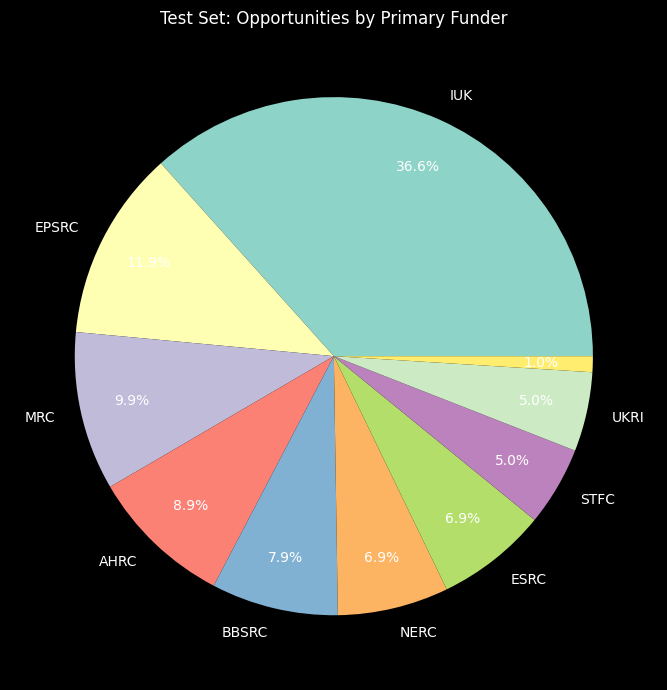

In [4]:
plot_samples = _test_samples.unique(subset=["id"])
funder_counts = plot_samples.group_by("primary_funder").len().sort("len", descending=True)
labels = funder_counts["primary_funder"].to_list()
sizes = funder_counts["len"].to_list()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sizes, labels=labels, autopct="%1.1f%%", pctdistance=0.8, textprops={"fontsize": 10})
ax.set_title("Test Set: Opportunities by Primary Funder")
fig.tight_layout()
plt.show()

### Opportunity Word Count Distributions by Council

/tmp/ipykernel_77746/1364273129.py:10: UserWarning: Comparisons with None always result in null. Consider using `.is_null()` or `.is_not_null()`.
  subset = plot_samples.filter(pl.col("primary_funder") == funder)


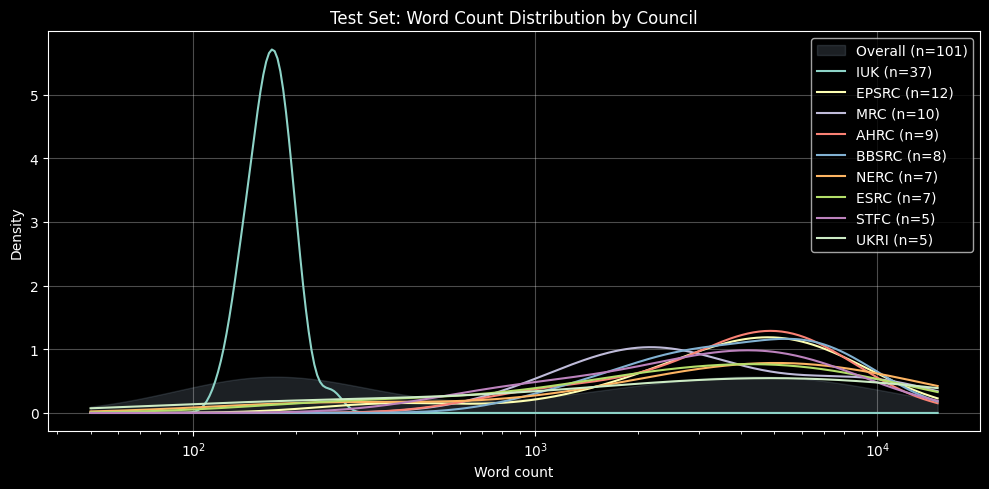

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x_grid = np.linspace(np.log10(50), np.log10(15000), 300)

overall_wc = np.log10(plot_samples["len_words"].to_numpy().clip(min=1))
kde_all = gaussian_kde(overall_wc)
ax.fill_between(10**x_grid, kde_all(x_grid), color="slategrey", alpha=0.25, label=f"Overall (n={len(plot_samples)})")

funders_sorted = funder_counts["primary_funder"].to_list()
for funder in funders_sorted:
    subset = plot_samples.filter(pl.col("primary_funder") == funder)
    if len(subset) < 2:
        continue
    wc = np.log10(subset["len_words"].to_numpy().clip(min=1))
    ax.plot(10**x_grid, gaussian_kde(wc)(x_grid), linewidth=1.5, label=f"{funder} (n={len(subset)})")

ax.set_xscale("log")
ax.set_xlabel("Word count")
ax.set_ylabel("Density")
ax.set_title("Test Set: Word Count Distribution by Council")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Load Annotated Test Set

Join existing test_samples with annotated test samples to ensure most up to date context is being used with the labels

In [27]:
# Load annotated test samples directly — this is the authoritative test set
ann_test_samples = pl.read_ndjson(str(Path(".").parent / "pipeline_experiment" / "test_samples.jsonl"))
test_samples = ann_test_samples.with_columns(
    metadata=pl.lit(None, dtype=pl.Utf8),
    title=pl.col("full_text").str.extract(r"^# (.+?)(?:\n|$)"),
)
print(f"Total: {len(test_samples)}, labeled: {test_samples['target_value'].drop_nulls().len()}, null: {test_samples['target_value'].null_count()}")
test_samples

Total: 489, labeled: 177, null: 312


shape: (489, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ id        ┆ full_text ┆ summary   ┆ sections  ┆ … ┆ question  ┆ target_va ┆ metadata ┆ title     │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ lue       ┆ ---      ┆ ---       │
│ str       ┆ str       ┆ str       ┆ list[stru ┆   ┆ str       ┆ ---       ┆ str      ┆ str       │
│           ┆           ┆           ┆ ct[3]]    ┆   ┆           ┆ str       ┆          ┆           │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What is   ┆ null      ┆ null     ┆ Funding   │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ the       ┆           ┆          ┆ opportuni │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ minimum   ┆           ┆          ┆ ty: Infor │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ fund      ┆           ┆          ┆ mati…     │
│           ┆           ┆ a…        ┆           ┆   ┆ value…    ┆           ┆          ┆           │
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What is   ┆ 250000    ┆ null     ┆ Funding   │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ the total ┆           ┆          ┆ opportuni │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ fund      ┆           ┆          ┆ ty: Infor │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ value (…  ┆           ┆          ┆ mati…     │
│           ┆           ┆ a…        ┆           ┆   ┆           ┆           ┆          ┆           │
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What perc ┆ 80        ┆ null     ┆ Funding   │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ entage    ┆           ┆          ┆ opportuni │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ (%) of    ┆           ┆          ┆ ty: Infor │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ the pro…  ┆           ┆          ┆ mati…     │
│           ┆           ┆ a…        ┆           ┆   ┆           ┆           ┆          ┆           │
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What is   ┆ null      ┆ null     ┆ Funding   │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ the       ┆           ┆          ┆ opportuni │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ minimum   ┆           ┆          ┆ ty: Infor │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ duration  ┆           ┆          ┆ mati…     │
│           ┆           ┆ a…        ┆           ┆   ┆ o…        ┆           ┆          ┆           │
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What is   ┆ five      ┆ null     ┆ Funding   │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ the       ┆ months    ┆          ┆ opportuni │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ maximum   ┆           ┆          ┆ ty: Infor │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ duration  ┆           ┆          ┆ mati…     │
│           ┆           ┆ a…        ┆           ┆   ┆ o…        ┆           ┆          ┆           │
│ …         ┆ …         ┆ …         ┆ …         ┆ … ┆ …         ┆ …         ┆ …        ┆ …         │
│ 6489fd2b- ┆ # Funding ┆ See the   ┆ []        ┆ … ┆ What is   ┆ null      ┆ null     ┆ Funding   │
│ a2ee-534b ┆ opportuni ┆ [full opp ┆           ┆   ┆ the       ┆           ┆          ┆ opportuni │
│ -8531-2a9 ┆ ty:       ┆ ortunity  ┆           ┆   ┆ maximum   ┆           ┆          ┆ ty:       │
│ 642…      ┆ Energy …  ┆ deta…     ┆           ┆   ┆ duration  ┆           ┆          ┆ Energy    │
│           ┆           ┆           ┆           ┆   ┆ o…        ┆           ┆          ┆ ca…       │
│ 83e9367e- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ What is   ┆ null      ┆ null     ┆ Funding   │
│ b222-591c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ the       ┆           ┆          ┆ opportuni │
│ -859d-fbf ┆ ty: BBSRC ┆ to        ┆ ",2,["

### Prompts, parsers, and matching

In [7]:
QUERY_VARIANTS = {
    "minimum_award": [
        "What is the minimum fund value?",
        "What is the minimum award amount per project?",
        "What is the smallest grant value available?",
    ],
    "maximum_award": [
        "What is the maximum fund value?",
        "What is the maximum award amount per project?",
        "What is the upper limit or ceiling of the grant?",
    ],
    "total_funding": [
        "What is the total fund value split among successful applications?",
        "What is the total funding available for this opportunity?",
        "What is the total budget or overall pot of money for this call?",
    ],
    "funding_percentage": [
        "What percentage of the project's funding will UKRI fund?",
        "What is the UKRI contribution percentage or fEC rate?",
        "What proportion or share of project costs will UKRI cover?",
    ],
    "minimum_funding_duration": [
        "What is the minimum duration of the project/funding?",
        "What is the minimum project length or term allowed?",
        "What is the shortest period a funded project can last?",
    ],
    "maximum_funding_duration": [
        "What is the maximum duration of the project/funding?",
        "What is the maximum project length or term allowed?",
        "How long can a funded project last?",
    ],
}

FIELD_LABELS = {
    "minimum_award": "Min Award",
    "maximum_award": "Max Award",
    "total_funding": "Total Funding",
    "funding_percentage": "% Funded",
    "minimum_funding_duration": "Min Duration",
    "maximum_funding_duration": "Max Duration",
}

In [8]:
WORD_TO_NUM = {
    "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
    "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
    "eleven": 11, "twelve": 12, "fifteen": 15, "eighteen": 18,
    "twenty": 20, "twenty-four": 24, "thirty": 30, "thirty-six": 36,
    "forty": 40, "forty-eight": 48, "fifty": 50, "sixty": 60,
}


def parse_pounds(text: str | None) -> int | None:
    """Parse a monetary value to integer pounds."""
    if text is None:
        return None
    text = str(text).replace(",", "").replace(" ", "").strip()
    if not text:
        return None
    try:
        return int(float(text))
    except ValueError:
        pass
    m = re.search(r"(?:£|Â£)?([\d.]+)\s*(million|m|billion|b|thousand|k)?", text, re.IGNORECASE)
    if m:
        value = float(m.group(1))
        unit = (m.group(2) or "").lower()
        multipliers = {"million": 1e6, "m": 1e6, "billion": 1e9, "b": 1e9, "thousand": 1e3, "k": 1e3}
        value *= multipliers.get(unit, 1)
        return int(value)
    return None


def parse_percentage(text: str | None) -> int | None:
    """Parse a percentage to integer."""
    if text is None:
        return None
    m = re.search(r"(\d+)\s*%?", str(text).strip())
    return int(m.group(1)) if m else None


def parse_duration_months(text: str | None) -> int | None:
    """Parse a duration string to integer months."""
    if text is None:
        return None
    text = str(text).lower().strip()
    if not text:
        return None
    for word, num in WORD_TO_NUM.items():
        text = re.sub(rf"\b{word}\b", str(num), text)
    total_months = 0
    for m in re.finditer(r"(\d+)\s*(year|month|week|day)s?", text):
        n = int(m.group(1))
        unit = m.group(2)
        if unit == "year":     total_months += n * 12
        elif unit == "month":  total_months += n
        elif unit == "week":   total_months += 0  # sub-month, not representable
        elif unit == "day":    total_months += 0
    return total_months if total_months > 0 else None


FIELD_PARSERS = {
    "minimum_award": parse_pounds,
    "maximum_award": parse_pounds,
    "total_funding": parse_pounds,
    "funding_percentage": parse_percentage,
    "minimum_funding_duration": parse_duration_months,
    "maximum_funding_duration": parse_duration_months,
}


def values_match(field: str, extracted: int | None, ground_truth: int | None) -> bool:
    """Compare parsed extracted value against parsed ground truth."""
    if extracted is None and ground_truth is None:
        return True
    if extracted is None or ground_truth is None:
        return False
    if field in ("minimum_funding_duration", "maximum_funding_duration"):
        return extracted == ground_truth
    if field == "funding_percentage":
        return extracted == ground_truth
    if ground_truth == 0:
        return extracted == 0
    return abs(extracted - ground_truth) / ground_truth <= 0.01

### Build inference datasets

Build datasets for all configurations: no-RAG baseline, then simple and hierarchical chunking across alpha values with and without the reranker. Save them to a single jsonl file to be batch queried offline.

In [14]:
SIMPLE_CHUNKING = [True, False]
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
USE_RR = [True, False]

In [ ]:
def build_dataset(
    test_df: pl.DataFrame,
    use_rag: bool = True,
    simple_chunking: bool = False,
    chunk_size: int = 200,
    chunk_overlap: int = 50,
    alpha: float = 0.5,
    use_reranker: bool = True,
) -> pl.DataFrame:
    """Build a dataset with retrieval contexts for each question row."""
    if not use_rag:
        rag = None
    elif simple_chunking:
        rag = SimpleChunkingPipeline(chunk_size=chunk_size, chunk_overlap=chunk_overlap, alpha=alpha, use_reranker=use_reranker)
    else:
        rag = RAGPipeline(alpha=alpha, use_reranker=use_reranker)

    contexts = []
    settings = {"use_rag": use_rag, "simple_chunking": simple_chunking, "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap, "alpha": alpha, "use_reranker": use_reranker}

    for (opp_id,), group in tqdm(test_df.group_by("id", maintain_order=True), desc="Building contexts"):
        first_row = group.row(0, named=True)
        full_text = first_row["full_text"]

        if use_rag and rag is not None:
            rag.clear()
            if simple_chunking:
                rag.index_text(full_text)
            else:
                rag.index(ParsedOpportunity(
                    title=first_row["title"],
                    summary=first_row["summary"],
                    sections=[Section.from_dict(s) for s in (first_row["sections"] or [])],
                    metadata=first_row["metadata"],
                ))

        for row in group.iter_rows(named=True):
            field = row["target_field"]
            question = row["question"]
            queries = QUERY_VARIANTS.get(field, [question])
            context = rag.query(queries) if use_rag and rag is not None else full_text
            contexts.append(context)

    return test_df.with_columns(context=pl.Series(contexts), settings=pl.lit(settings))

# Build RAG datasets
datasets = []
for (simple_chunking, alpha, use_rr) in tqdm(list(product(SIMPLE_CHUNKING, ALPHAS, USE_RR)), desc="Building datasets"):
    datasets.append(build_dataset(
        test_df=test_samples,
        use_rag=True,
        simple_chunking=simple_chunking,
        alpha=alpha,
        use_reranker=use_rr,
    ))

# Build non-RAG dataset
datasets.append(build_dataset(
    test_df=test_samples,
    use_rag=False,
    simple_chunking=False,
    alpha=0.0,
    use_reranker=False,
))

datasets = pl.concat(datasets, how="vertical")
datasets.write_ndjson(Path(".").parent / "pipeline_experiment" / "dataset_permutations.jsonl")
datasets

## Load in Model Outputs

In [28]:
def _extract_answer(content: str | None) -> str | None:
    """Robustly extract the answer from a model response."""
    if content is None:
        return None
    c = content.strip().removeprefix("```json").removesuffix("```").strip()
    try:
        obj = json.loads(c)
    except json.JSONDecodeError:
        # Some responses use commas instead of colons: {"key", "value"}
        # Try replacing first comma with colon
        c2 = c.replace(",", ":", 1)
        try:
            obj = json.loads(c2)
        except json.JSONDecodeError:
            return None
    if isinstance(obj, dict):
        # Get the first (and usually only) value regardless of key name
        val = next(iter(obj.values()), None)
        if val is None:
            return None
        text = str(val).strip()
        return None if text.upper() == "UNKNOWN" else text
    return None

_raw_results = pl.read_ndjson(Path(".").parent / "pipeline_experiment" / "dataset_permutations_results.jsonl")

responses = [
    _extract_answer(row["_response"]["choices"][0]["message"]["content"])
    for row in _raw_results.select("_response").to_dicts()
]

_ann_labels = ann_test_samples.select("id", "target_field", "target_value")

test_results = (
    _raw_results
    .drop("target_value")
    .with_columns(response=pl.Series(responses))
    .join(_ann_labels, on=("id", "target_field"), how="inner")
)

n_configs = test_results["settings"].n_unique()
n_samples = test_results.select("id", "target_field").unique().height
n_null_responses = sum(1 for r in responses if r is None)
n_with_value = sum(1 for r in responses if r is not None)
print(f"Results: {len(test_results)} ({n_samples} samples × {n_configs} configs)")
print(f"With labels: {test_results['target_value'].drop_nulls().len()}, null: {test_results['target_value'].null_count()}")
print(f"Model responses: {n_with_value} with value, {n_null_responses} null (not found)")
test_results

Results: 10269 (489 samples × 21 configs)
With labels: 3717, null: 6552
Model responses: 4511 with value, 5758 null (not found)


shape: (10_269, 19)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ full_text ┆ summary   ┆ sections  ┆ … ┆ _model_kw ┆ _timestam ┆ response  ┆ target_v │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ args      ┆ p         ┆ ---       ┆ alue     │
│ str       ┆ str       ┆ str       ┆ list[stru ┆   ┆ ---       ┆ ---       ┆ str       ┆ ---      │
│           ┆           ┆           ┆ ct[3]]    ┆   ┆ struct[4] ┆ f64       ┆           ┆ str      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 994cf55c- ┆ # Funding ┆ See the   ┆ []        ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ 14000000  ┆ null     │
│ fd75-5785 ┆ opportuni ┆ [full opp ┆           ┆   ┆ 0,"http:/ ┆           ┆           ┆          │
│ -be28-d99 ┆ ty:       ┆ ortunity  ┆           ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ a01…      ┆ Contrac…  ┆ deta…     ┆           ┆   ┆ 300…      ┆           ┆           ┆          │
│ 15e9e01c- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ 80        ┆ 80       │
│ df86-5df0 ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ 0,"http:/ ┆           ┆           ┆          │
│ -9e17-068 ┆ ty: Early ┆ to        ┆ ",2,["Thi ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ ca7…      ┆ c…        ┆ conduct   ┆ s opp…    ┆   ┆ 300…      ┆           ┆           ┆          │
│           ┆           ┆ r…        ┆           ┆   ┆           ┆           ┆           ┆          │
│ d8e360b3- ┆ # Funding ┆ This      ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ 3 years   ┆ three    │
│ fb98-5ec7 ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ 0,"http:/ ┆           ┆           ┆ years    │
│ -823c-603 ┆ ty: EPSRC ┆ opportuni ┆ ",2,["Res ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ ed3…      ┆ n…        ┆ ty is no… ┆ earch…    ┆   ┆ 300…      ┆           ┆           ┆          │
│ 994cf55c- ┆ # Funding ┆ See the   ┆ []        ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ null      ┆ null     │
│ fd75-5785 ┆ opportuni ┆ [full opp ┆           ┆   ┆ 0,"http:/ ┆           ┆           ┆          │
│ -be28-d99 ┆ ty:       ┆ ortunity  ┆           ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ a01…      ┆ Contrac…  ┆ deta…     ┆           ┆   ┆ 300…      ┆           ┆           ┆          │
│ 7213fba6- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ 80        ┆ 80       │
│ 0a2e-5b8c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ 0,"http:/ ┆           ┆           ┆          │
│ -a939-a68 ┆ ty:       ┆ to        ┆ ",2,["Sta ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ db4…      ┆ Informa…  ┆ develop   ┆ ndard…    ┆   ┆ 300…      ┆           ┆           ┆          │
│           ┆           ┆ a…        ┆           ┆   ┆           ┆           ┆           ┆          │
│ …         ┆ …         ┆ …         ┆ …         ┆ … ┆ …         ┆ …         ┆ …         ┆ …        │
│ 83e9367e- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ eight     ┆ null     │
│ b222-591c ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ 0,"http:/ ┆           ┆ weeks     ┆          │
│ -859d-fbf ┆ ty: BBSRC ┆ to        ┆ ",2,["BBS ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ b68…      ┆ I…        ┆ discover  ┆ RC IC…    ┆   ┆ 300…      ┆           ┆           ┆          │
│           ┆           ┆ …         ┆           ┆   ┆           ┆           ┆           ┆          │
│ b43ece92- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ 5 years   ┆ 5 years  │
│ d6ab-56e1 ┆ opportuni ┆ funding   ┆ can apply ┆   ┆ 0,"http:/ ┆           ┆           ┆          │
│ -bdcc-7ef ┆ ty: Build ┆ to build  ┆ ",2,["Sta ┆   ┆ /0.0.0.0: ┆           ┆           ┆          │
│ 943…      ┆ o…        ┆ on …      ┆ ndard…    ┆   ┆ 300…      ┆           ┆           ┆          │
│ b43ece92- ┆ # Funding ┆ Apply for ┆ [{"Who    ┆ … ┆ {1.0,1.0, ┆ 1.7741e9  ┆ null      ┆ null     │
│ d6ab-56e1 ┆ opportuni ┆ funding   ┆ can

### Evaluate: parse and match

In [10]:
# Parse both sides and compute match for every result row
evaluated = []
for row in test_results.iter_rows(named=True):
    field = row["target_field"]
    parser = FIELD_PARSERS[field]

    gt_parsed = parser(row["target_value"])
    ex_parsed = parser(row["response"])
    match = values_match(field, ex_parsed, gt_parsed)

    settings = row["settings"]
    if not settings["use_rag"]:
        config_key = "no_rag"
    else:
        strategy = "simple" if settings["simple_chunking"] else "hierarchical"
        alpha = str(settings["alpha"]).replace(".", "_")
        rr = "reranker" if settings["use_reranker"] else "no-reranker"
        config_key = f"{strategy}_alpha{alpha}_{rr}"

    evaluated.append({
        "id": row["id"],
        "full_text": row["full_text"],
        "target_field": field,
        "config": config_key,
        "ground_truth_raw": row["target_value"],
        "ground_truth_parsed": gt_parsed,
        "extracted_raw": row["response"],
        "extracted": ex_parsed,
        "match": match,
    })

evaluated_df = pl.DataFrame(evaluated)
print(f"Evaluated: {len(evaluated_df)}")
print(f"Overall match rate: {evaluated_df['match'].mean():.1%}")
evaluated_df

Evaluated: 10269
Overall match rate: 83.9%


id,full_text,target_field,config,ground_truth_raw,ground_truth_parsed,extracted_raw,extracted,match
str,str,str,str,str,i64,str,i64,bool
"""994cf55c-fd75-5785-be28-d99a01…","""# Funding opportunity: Contrac…","""maximum_award""","""simple_alpha0_0_reranker""",null,null,"""14000000""",14000000,false
"""15e9e01c-df86-5df0-9e17-068ca7…","""# Funding opportunity: Early c…","""funding_percentage""","""simple_alpha0_0_reranker""","""80""",80,"""80""",80,true
"""d8e360b3-fb98-5ec7-823c-603ed3…","""# Funding opportunity: EPSRC n…","""maximum_funding_duration""","""simple_alpha0_0_reranker""","""three years""",36,"""3 years""",36,true
"""994cf55c-fd75-5785-be28-d99a01…","""# Funding opportunity: Contrac…","""minimum_funding_duration""","""simple_alpha0_0_reranker""",null,null,null,null,true
"""7213fba6-0a2e-5b8c-a939-a68db4…","""# Funding opportunity: Informa…","""funding_percentage""","""simple_alpha0_0_reranker""","""80""",80,"""80""",80,true
…,…,…,…,…,…,…,…,…
"""83e9367e-b222-591c-859d-fbfb68…","""# Funding opportunity: BBSRC I…","""minimum_funding_duration""","""no_rag""",null,null,"""eight weeks""",null,true
"""b43ece92-d6ab-56e1-bdcc-7ef943…","""# Funding opportunity: Build o…","""maximum_funding_duration""","""no_rag""","""5 years""",60,"""5 years""",60,true
"""b43ece92-d6ab-56e1-bdcc-7ef943…","""# Funding opportunity: Build o…","""total_funding""","""no_rag""",null,null,null,null,true


In [11]:
def summarise(results: list[dict]) -> dict:
    total = len(results)
    matched = sum(1 for r in results if r["match"])
    unknown = sum(1 for r in results if r["extracted"] is None)
    errors = sum(1 for r in results if "error" in r)

    by_field: dict[str, dict] = {}
    for r in results:
        s = by_field.setdefault(r["target_field"], {"total": 0, "matched": 0, "unknown": 0, "errors": 0})
        s["total"] += 1
        if r["match"]:              s["matched"] += 1
        if r["extracted"] is None:  s["unknown"] += 1
        if "error" in r:            s["errors"] += 1

    for s in by_field.values():
        n = s["total"]
        s["accuracy"] = s["matched"] / n if n else 0.0
        s["unknown_rate"] = s["unknown"] / n if n else 0.0

    return {
        "total_fields": total, "matched": matched,
        "unknown": unknown, "errors": errors,
        "accuracy": matched / total if total else 0.0,
        "unknown_rate": unknown / total if total else 0.0,
        "by_field": by_field,
    }

# Build all_summaries dict keyed by config
all_summaries = {}
for config_key, group in evaluated_df.group_by("config"):
    config_key = config_key[0]
    rows = group.to_dicts()
    all_summaries[config_key] = summarise(rows)

# Quick summary
for k in sorted(all_summaries.keys()):
    s = all_summaries[k]
    print(f"{k:<45} acc={s['accuracy']:.1%}  ({s['matched']}/{s['total_fields']})")

hierarchical_alpha0_0_no-reranker             acc=83.6%  (409/489)
hierarchical_alpha0_0_reranker                acc=87.1%  (426/489)
hierarchical_alpha0_25_no-reranker            acc=87.7%  (429/489)
hierarchical_alpha0_25_reranker               acc=86.9%  (425/489)
hierarchical_alpha0_5_no-reranker             acc=86.7%  (424/489)
hierarchical_alpha0_5_reranker                acc=86.1%  (421/489)
hierarchical_alpha0_75_no-reranker            acc=87.1%  (426/489)
hierarchical_alpha0_75_reranker               acc=85.1%  (416/489)
hierarchical_alpha1_0_no-reranker             acc=86.1%  (421/489)
hierarchical_alpha1_0_reranker                acc=86.1%  (421/489)
no_rag                                        acc=85.3%  (417/489)
simple_alpha0_0_no-reranker                   acc=83.4%  (408/489)
simple_alpha0_0_reranker                      acc=82.8%  (405/489)
simple_alpha0_25_no-reranker                  acc=80.8%  (395/489)
simple_alpha0_25_reranker                     acc=83.6%  (409/

### Results table

In [12]:
def build_results_table(summaries: dict[str, dict]) -> pl.DataFrame:
    """Build a polars DataFrame from the experiment summaries."""
    rows = []
    for label, summary in summaries.items():
        if label == "no_rag":
            strategy, alpha, reranker = "none", None, None
        else:
            m = re.match(r"(hierarchical|simple)_alpha([\d_]+)_(no-reranker|reranker)", label)
            strategy = m.group(1)
            alpha = float(m.group(2).replace("_", "."))
            reranker = m.group(3) == "reranker"

        row = {
            "strategy": strategy,
            "alpha": alpha,
            "reranker": reranker,
            "overall_acc": summary["accuracy"],
            "overall_unk": summary["unknown_rate"],
        }
        for field, label_name in FIELD_LABELS.items():
            row[label_name] = summary["by_field"].get(field, {}).get("accuracy", float("nan"))
        rows.append(row)

    df = pl.DataFrame(rows)
    order = {"none": 0, "simple": 1, "hierarchical": 2}
    df = df.sort(
        pl.col("strategy").replace_strict(order).cast(pl.Int8),
        pl.col("alpha"),
        pl.col("reranker"),
    )
    return df


results_df = build_results_table(all_summaries)
results_df

strategy,alpha,reranker,overall_acc,overall_unk,Min Award,Max Award,Total Funding,% Funded,Min Duration,Max Duration
str,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64
"""none""",null,null,0.852761,0.533742,0.835294,0.597222,0.724138,0.980198,0.871287,0.940594
"""simple""",0.0,false,0.834356,0.582822,0.894118,0.597222,0.793103,0.940594,0.831683,0.861386
"""simple""",0.0,true,0.828221,0.539877,0.776471,0.569444,0.689655,0.950495,0.871287,0.930693
"""simple""",0.25,false,0.807771,0.586912,0.823529,0.555556,0.827586,0.851485,0.851485,0.881188
"""simple""",0.25,true,0.836401,0.533742,0.764706,0.597222,0.793103,0.960396,0.861386,0.930693
…,…,…,…,…,…,…,…,…,…,…
"""hierarchical""",0.5,true,0.860941,0.574642,0.882353,0.638889,0.724138,0.960396,0.881188,0.920792
"""hierarchical""",0.75,false,0.871166,0.550102,0.882353,0.652778,0.724138,1.0,0.841584,0.960396
"""hierarchical""",0.75,true,0.850716,0.562372,0.870588,0.611111,0.724138,0.960396,0.861386,0.920792


In [26]:
def pct(v: float) -> str:
    return f"{v * 100:.1f}"

def fmt(v: float, best: float) -> str:
    s = pct(v)
    return rf"\textbf{{{s}}}" if v >= best else s

def make_latex_table(summaries: dict[str, dict]) -> str:
    FIELDS = list(FIELD_LABELS.keys())
    FIELD_SHORT = {
        "minimum_award": "Min",
        "maximum_award": "Max",
        "total_funding": "Total",
        "funding_percentage": r"\% Funded",
        "minimum_funding_duration": "Min Dur",
        "maximum_funding_duration": "Max Dur",
    }
    CHUNKER_LABEL = {"none": "None", "simple": "Simple", "hierarchical": "Hierarchical"}
    ORDER = {"none": 0, "simple": 1, "hierarchical": 2}

    rows = []
    for label, summary in summaries.items():
        if label == "no_rag":
            strategy, alpha, reranker = "none", None, None
        else:
            m = re.match(r"(hierarchical|simple)_alpha([\d_]+)_(no-reranker|reranker)", label)
            strategy = m.group(1)
            alpha = float(m.group(2).replace("_", "."))
            reranker = m.group(3) == "reranker"

        row = {
            "strategy": strategy,
            "alpha": alpha,
            "reranker": reranker,
            "overall_acc": summary["accuracy"],
            "overall_unk": summary["unknown_rate"],
        }
        for field in FIELDS:
            row[field] = summary["by_field"].get(field, {}).get("accuracy", float("nan"))
        rows.append(row)

    rows.sort(key=lambda r: (ORDER[r["strategy"]], r["alpha"] or 0, r["reranker"] or False))

    # Column bests
    best_acc = {f: max(r[f] for r in rows) for f in FIELDS + ["overall_acc"]}
    best_unk = min(r["overall_unk"] for r in rows)

    n_fields = len(FIELDS)
    body_lines = []
    prev_strategy = None
    for row in rows:
        if prev_strategy is not None and row["strategy"] != prev_strategy:
            body_lines.append(r"    \addlinespace")
        prev_strategy = row["strategy"]

        chunker = CHUNKER_LABEL[row["strategy"]]
        alpha_cell = "---" if row["alpha"] is None else f"{row['alpha']:.2f}"
        rr = r"\checkmark" if row["reranker"] else ""
        field_accs = " & ".join(fmt(row[f], best_acc[f]) for f in FIELDS)
        unk_s = pct(row["overall_unk"])
        unk_fmt = rf"\textbf{{{unk_s}}}" if row["overall_unk"] <= best_unk else unk_s
        body_lines.append(
            f"    {chunker} & {alpha_cell} & {rr} & "
            f"{field_accs} & "
            f"{fmt(row['overall_acc'], best_acc['overall_acc'])} & "
            f"{unk_fmt} \\\\"
        )

    body = "\n".join(body_lines)
    field_headers = " & ".join(FIELD_SHORT[f] for f in FIELDS)

    table = rf"""\begin{{table*}}
\centering
\small
\begin{{tabular}}{{llc{'c' * n_fields}cc}}
\toprule
\multicolumn{{2}}{{c}}{{Configuration}} & & \multicolumn{{{n_fields}}}{{c}}{{Field Accuracy (\%)}} & \multicolumn{{2}}{{c}}{{Overall}} \\
\cmidrule(lr){{1-2}} \cmidrule(lr){{4-{3 + n_fields}}} \cmidrule(lr){{{4 + n_fields}-{5 + n_fields}}}
Chunker & $\alpha$ & RR & {field_headers} & Acc (\%) & Unk (\%) \\
\midrule
{body}
\bottomrule
\end{{tabular}}
\caption{{Extraction accuracy across retrieval configurations. RR = re-ranker enabled. Min/Max/Total = minimum, maximum, total award (\pounds). \% Funded = UKRI contribution percentage. Min/Max Dur = minimum, maximum funding duration. Configurations are grouped by chunking strategy; within each group, rows are ordered by $\alpha$.}}
\label{{tab:extraction-results}}
\end{{table*}}"""
    return table

print(make_latex_table(all_summaries))

\begin{table*}
\centering
\small
\begin{tabular}{llccccccccc}
\toprule
\multicolumn{2}{c}{Configuration} & & \multicolumn{6}{c}{Field Accuracy (\%)} & \multicolumn{2}{c}{Overall} \\
\cmidrule(lr){1-2} \cmidrule(lr){4-9} \cmidrule(lr){10-11}
Chunker & $\alpha$ & RR & Min & Max & Total & \% Funded & Min Dur & Max Dur & Acc (\%) & Unk (\%) \\
\midrule
    None & --- &  & 83.5 & 59.7 & 72.4 & 98.0 & 87.1 & 94.1 & 85.3 & 53.4 \\
    \addlinespace
    Simple & 0.00 &  & \textbf{89.4} & 59.7 & 79.3 & 94.1 & 83.2 & 86.1 & 83.4 & 58.3 \\
    Simple & 0.00 & \checkmark & 77.6 & 56.9 & 69.0 & 95.0 & 87.1 & 93.1 & 82.8 & 54.0 \\
    Simple & 0.25 &  & 82.4 & 55.6 & \textbf{82.8} & 85.1 & 85.1 & 88.1 & 80.8 & 58.7 \\
    Simple & 0.25 & \checkmark & 76.5 & 59.7 & 79.3 & 96.0 & 86.1 & 93.1 & 83.6 & 53.4 \\
    Simple & 0.50 &  & \textbf{89.4} & 61.1 & 75.9 & 78.2 & 85.1 & 88.1 & 81.0 & 63.2 \\
    Simple & 0.50 & \checkmark & 77.6 & 61.1 & 72.4 & 94.1 & 86.1 & 92.1 & 83.0 & 54.0 \\
    Simple & 0.75

### Plots

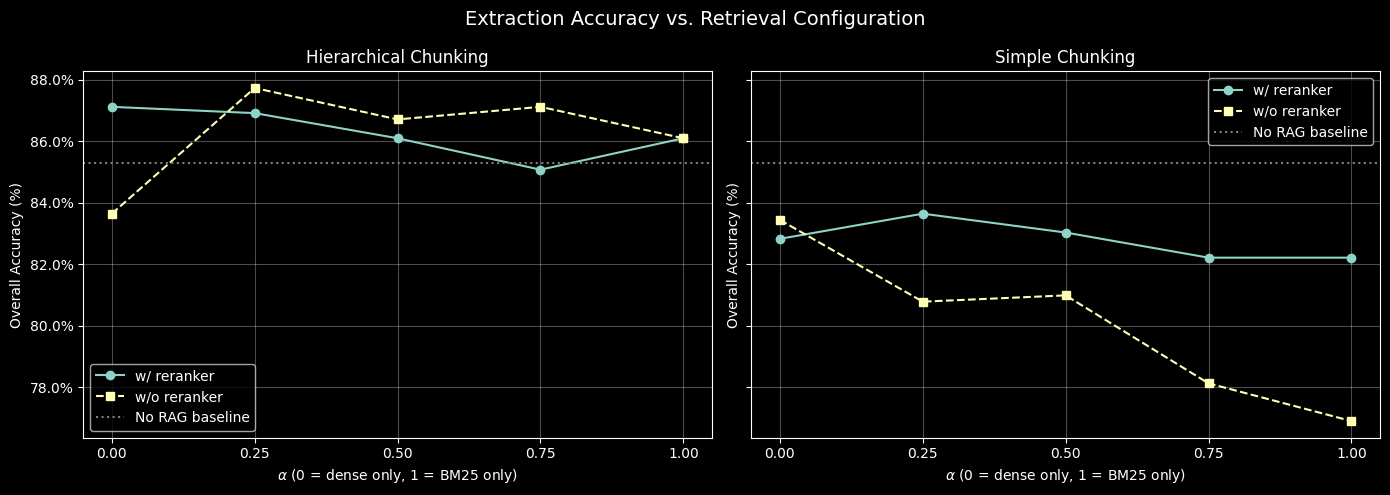

In [15]:
rag_df = results_df.filter(pl.col("strategy") != "none")
no_rag_acc = results_df.filter(pl.col("strategy") == "none")["overall_acc"][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (strat_label, strat_name) in zip(axes, [("hierarchical", "Hierarchical"), ("simple", "Simple")]):
    strat = rag_df.filter(pl.col("strategy") == strat_label)

    for use_rr, marker, ls in [(True, "o", "-"), (False, "s", "--")]:
        subset = strat.filter(pl.col("reranker") == use_rr).sort("alpha")
        rr_label = "w/ reranker" if use_rr else "w/o reranker"
        ax.plot(
            subset["alpha"].to_list(),
            [v * 100 for v in subset["overall_acc"].to_list()],
            marker=marker, linestyle=ls, label=rr_label,
        )

    ax.axhline(no_rag_acc * 100, color="grey", linestyle=":", label="No RAG baseline")
    ax.set_title(f"{strat_name} Chunking")
    ax.set_xlabel(r"$\alpha$ (0 = dense only, 1 = BM25 only)")
    ax.set_ylabel("Overall Accuracy (%)")
    ax.legend()
    ax.set_xticks(ALPHAS)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(True, alpha=0.3)

fig.suptitle("Extraction Accuracy vs. Retrieval Configuration", fontsize=14)
fig.tight_layout()
plt.show()

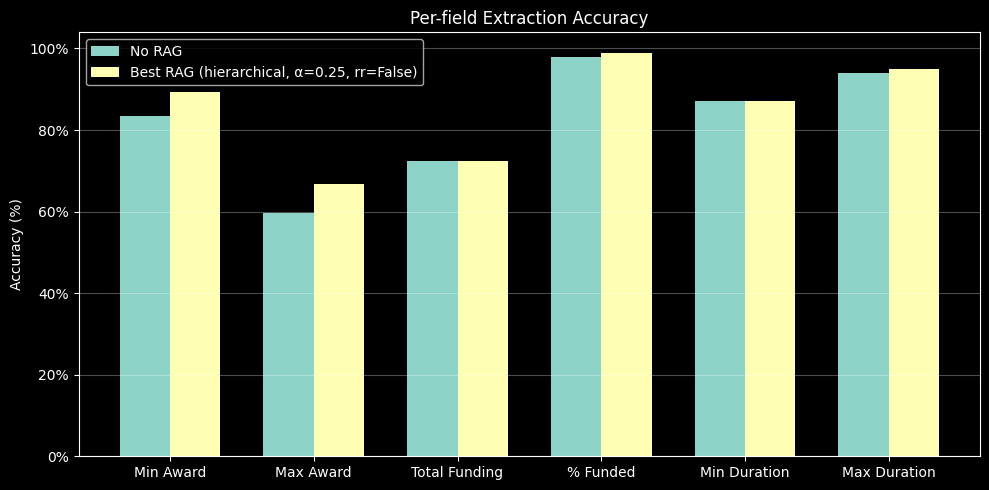

In [16]:
best_row = results_df.filter(pl.col("strategy") != "none").sort("overall_acc", descending=True).row(0, named=True)
no_rag_row = results_df.filter(pl.col("strategy") == "none").row(0, named=True)

field_labels = list(FIELD_LABELS.values())
best_accs = [best_row[lbl] * 100 for lbl in field_labels]
norag_accs = [no_rag_row[lbl] * 100 for lbl in field_labels]

x = np.arange(len(field_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width / 2, norag_accs, width, label="No RAG")
ax.bar(x + width / 2, best_accs, width, label=f"Best RAG ({best_row['strategy']}, α={best_row['alpha']}, rr={best_row['reranker']})")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-field Extraction Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(field_labels)
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

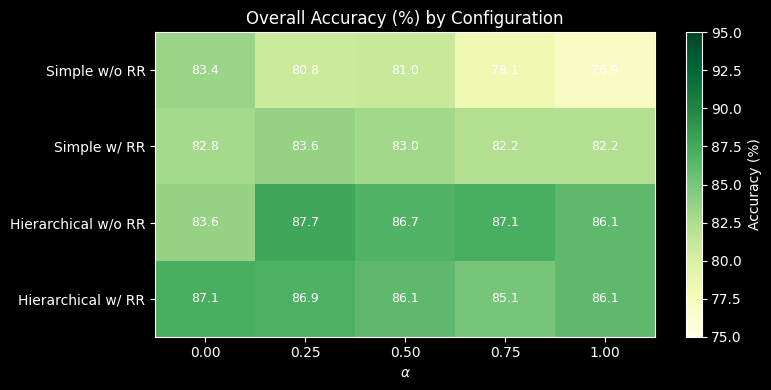

In [17]:
pivot_rows = []
for _, row in enumerate(rag_df.iter_rows(named=True)):
    rr_tag = "w/ RR" if row["reranker"] else "w/o RR"
    pivot_rows.append({
        "config": f"{row['strategy'].title()} {rr_tag}",
        "alpha": row["alpha"],
        "accuracy": row["overall_acc"] * 100,
    })

pivot_df = pl.DataFrame(pivot_rows)
configs = pivot_df["config"].unique(maintain_order=True).to_list()
alphas = sorted(pivot_df["alpha"].unique().to_list())

heat = np.full((len(configs), len(ALPHAS)), np.nan)
for row in pivot_df.iter_rows(named=True):
    i = configs.index(row["config"])
    j = alphas.index(row["alpha"])
    heat[i, j] = row["accuracy"]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heat, aspect="auto", cmap="YlGn", vmin=75, vmax=95)
ax.set_xticks(range(len(alphas)), [f"{a:.2f}" for a in alphas])
ax.set_yticks(range(len(configs)), configs)
ax.set_xlabel(r"$\alpha$")
ax.set_title("Overall Accuracy (%) by Configuration")

for i in range(len(configs)):
    for j in range(len(alphas)):
        if not np.isnan(heat[i, j]):
            ax.text(j, i, f"{heat[i, j]:.1f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, label="Accuracy (%)")
fig.tight_layout()
plt.show()

## Error Analysis

Analyse errors on the best RAG configuration to identify systematic failure modes.

In [18]:
# Classify every evaluated row by error type
from collections import Counter

def classify_error(row: dict) -> str:
    gt, ex = row["ground_truth_parsed"], row["extracted"]
    if row["match"]:
        return "true_negative" if gt is None and ex is None else "true_positive"
    if gt is None and ex is not None:
        return "false_positive"
    if gt is not None and ex is None:
        return "false_negative"
    return "value_mismatch"

# Use best config for analysis
best_config = results_df.filter(pl.col("strategy") != "none").sort("overall_acc", descending=True).row(0, named=True)
best_key = f"{best_config['strategy']}_alpha{str(best_config['alpha']).replace('.', '_')}_{('reranker' if best_config['reranker'] else 'no-reranker')}"
print(f"Analysing config: {best_key} (accuracy: {best_config['overall_acc']:.1%})")

best_eval = evaluated_df.filter(pl.col("config") == best_key).to_dicts()
for row in best_eval:
    row["error_type"] = classify_error(row)

error_df = pl.DataFrame(best_eval)
type_counts = error_df.group_by("error_type").len().sort("len", descending=True)
print("\nOverall breakdown:")
for row in type_counts.iter_rows(named=True):
    print(f"  {row['error_type']:20s} {row['len']:>4}  ({row['len']/len(best_eval):.1%})")

errors_only = error_df.filter(~pl.col("match"))
print(f"\nTotal errors: {len(errors_only)} / {len(best_eval)}")

Analysing config: hierarchical_alpha0_25_no-reranker (accuracy: 87.7%)

Overall breakdown:
  true_negative         267  (54.6%)
  true_positive         162  (33.1%)
  false_positive         47  (9.6%)
  value_mismatch          9  (1.8%)
  false_negative          4  (0.8%)

Total errors: 60 / 489


### Errors by field and type

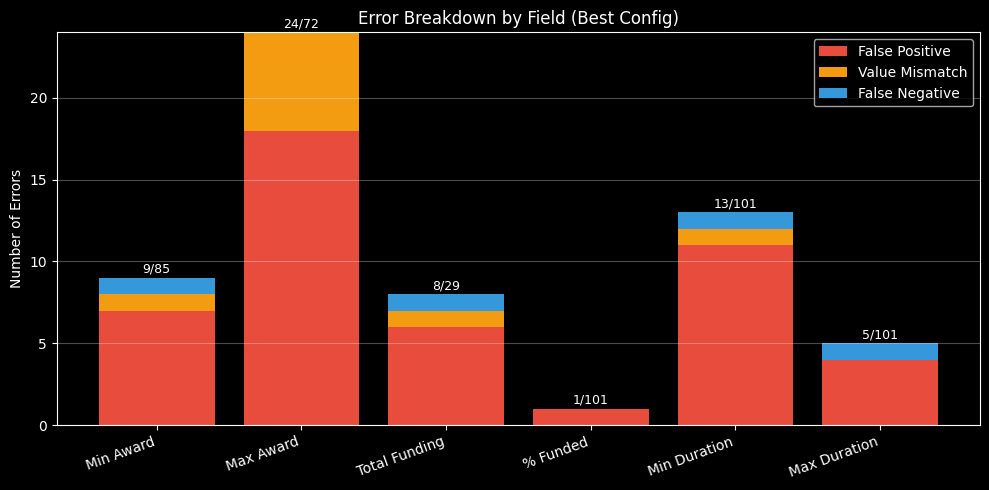

In [19]:
# Stacked bar chart: error types by field
error_types = ["false_positive", "value_mismatch", "false_negative"]
error_colors = {"false_positive": "#e74c3c", "value_mismatch": "#f39c12", "false_negative": "#3498db"}
fields = list(FIELD_LABELS.keys())
field_names = list(FIELD_LABELS.values())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fields))
bottoms = np.zeros(len(fields))

for err_type in error_types:
    counts = []
    for field in fields:
        n = errors_only.filter(
            (pl.col("target_field") == field) & (pl.col("error_type") == err_type)
        ).height
        counts.append(n)
    ax.bar(x, counts, bottom=bottoms, label=err_type.replace("_", " ").title(),
           color=error_colors[err_type])
    bottoms += np.array(counts)

# Add total count for each field
field_totals = errors_only.group_by("target_field").len()
for field in fields:
    total_for_field = error_df.filter(pl.col("target_field") == field).height
    n_errors = errors_only.filter(pl.col("target_field") == field).height
    idx = fields.index(field)
    if n_errors > 0:
        ax.text(idx, bottoms[idx] + 0.3, f"{n_errors}/{total_for_field}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(field_names, rotation=20, ha="right")
ax.set_ylabel("Number of Errors")
ax.set_title("Error Breakdown by Field (Best Config)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### False positive analysis: field confusion

For false positives (model answered when ground truth is null), check whether the hallucinated value actually belongs to a different field for the same opportunity.

In [20]:
# For each false positive, check if the model's answer matches another field's ground truth
opp_labels = {}
for row in ann_test_samples.iter_rows(named=True):
    opp_labels.setdefault(row["id"], {})[row["target_field"]] = row.get("target_value")

fps = errors_only.filter(pl.col("error_type") == "false_positive").to_dicts()

confusion_source = []
for row in fps:
    opp_gt = opp_labels.get(row["id"], {})
    source = "hallucination"
    for other_field, other_val in opp_gt.items():
        if other_field == row["target_field"] or other_val is None:
            continue
        other_parsed = FIELD_PARSERS[other_field](other_val)
        if other_parsed is not None and row["extracted"] is not None and other_parsed == row["extracted"]:
            source = other_field
            break
    confusion_source.append(source)

fp_df = pl.DataFrame(fps).with_columns(confusion_source=pl.Series(confusion_source))

# Confusion matrix: asked_for × actually_from
print("False positive sources (what field did the model's answer actually come from?):\n")
source_counts = fp_df.group_by("target_field", "confusion_source").len().sort("target_field", "len", descending=[False, True])
for row in source_counts.iter_rows(named=True):
    label = FIELD_LABELS.get(row["target_field"], row["target_field"])
    print(f"  {label:20s} ← {row['confusion_source']:30s} ({row['len']})")

# Summary
n_confused = fp_df.filter(pl.col("confusion_source") != "hallucination").height
n_halluc = fp_df.filter(pl.col("confusion_source") == "hallucination").height
print(f"\nField confusion: {n_confused}/{len(fps)} ({n_confused/len(fps):.0%})")
print(f"Pure hallucination: {n_halluc}/{len(fps)} ({n_halluc/len(fps):.0%})")

False positive sources (what field did the model's answer actually come from?):

  % Funded             ← hallucination                  (1)
  Max Award            ← hallucination                  (14)
  Max Award            ← total_funding                  (4)
  Max Duration         ← hallucination                  (3)
  Max Duration         ← minimum_funding_duration       (1)
  Min Award            ← hallucination                  (7)
  Min Duration         ← maximum_funding_duration       (9)
  Min Duration         ← hallucination                  (2)
  Total Funding        ← hallucination                  (3)
  Total Funding        ← maximum_award                  (2)
  Total Funding        ← funding_percentage             (1)

Field confusion: 17/47 (36%)
Pure hallucination: 30/47 (64%)


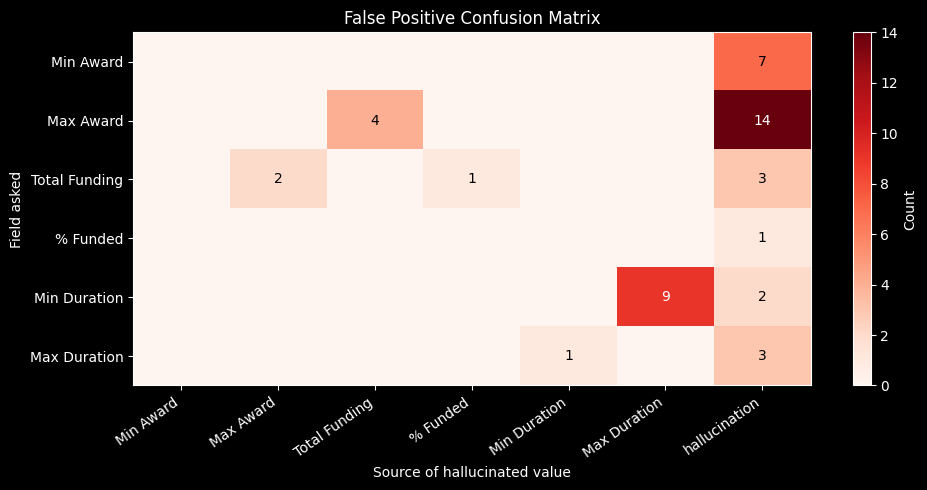

In [21]:
# Confusion heatmap: which fields get confused for which?
confusion_fields = list(FIELD_LABELS.keys()) + ["hallucination"]
confusion_labels = [FIELD_LABELS.get(f, f) for f in confusion_fields]
asked_fields = list(FIELD_LABELS.keys())
asked_labels = list(FIELD_LABELS.values())

heat = np.zeros((len(asked_fields), len(confusion_fields)))
for row in fp_df.iter_rows(named=True):
    i = asked_fields.index(row["target_field"])
    j = confusion_fields.index(row["confusion_source"])
    heat[i, j] += 1

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heat, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(confusion_fields)))
ax.set_xticklabels(confusion_labels, rotation=35, ha="right")
ax.set_yticks(range(len(asked_fields)))
ax.set_yticklabels(asked_labels)
ax.set_xlabel("Source of hallucinated value")
ax.set_ylabel("Field asked")
ax.set_title("False Positive Confusion Matrix")

for i in range(len(asked_fields)):
    for j in range(len(confusion_fields)):
        if heat[i, j] > 0:
            ax.text(j, i, f"{int(heat[i, j])}", ha="center", va="center", fontsize=10,
                    color="white" if heat[i, j] > heat.max() / 2 else "black")

fig.colorbar(im, ax=ax, label="Count")
fig.tight_layout()
plt.show()

### Value mismatch examples

Cases where both the model and ground truth have a value but they disagree.

In [22]:
# Show all value mismatches
vms = errors_only.filter(pl.col("error_type") == "value_mismatch").to_dicts()

if vms:
    print(f"Value mismatches: {len(vms)}\n")
    print(f"{'Field':<22} {'Ground Truth':>20} {'Model':>20}  Opportunity")
    print(f"{'-'*22} {'-'*20} {'-'*20}  {'-'*40}")
    for row in vms:
        label = FIELD_LABELS.get(row["target_field"], row["target_field"])
        gt_str = f"{row['ground_truth_raw']} ({row['ground_truth_parsed']})"
        ex_str = f"{row['extracted_raw']} ({row['extracted']})"
        opp_title = re.search(r"# (.+?)(?:\n|$)", 
            ann_test_samples.filter(pl.col("id") == row["id"]).row(0, named=True).get("full_text", ""))
        title = opp_title.group(1)[:40] if opp_title else "?"
        print(f"{label:<22} {gt_str:>20} {ex_str:>20}  {title}")
else:
    print("No value mismatches.")

Value mismatches: 9

Field                          Ground Truth                Model  Opportunity
---------------------- -------------------- --------------------  ----------------------------------------
Max Award                   200000 (200000)    2000000 (2000000)  Funding opportunity: MyWorld collaborati
Total Funding           62500000 (62500000) 37500000-62500000 (37500000)  Funding opportunity: Research and partne
Max Award                 1500000 (1500000)    1200000 (1200000)  Funding opportunity: AHRC responsive mod
Min Award                 1250000 (1250000)      250000 (250000)  Funding opportunity: Accelerate the impa
Max Award                 1000000 (1000000)      800000 (800000)  Funding opportunity: ESRC responsive mod
Max Award                 1000000 (1000000)      800000 (800000)  Funding opportunity: ESRC responsive mod
Min Duration                   3 years (36) less than two years (24)  Funding opportunity: MRC Neurosciences a
Max Award                   30000

### False negative examples

Cases where the ground truth has a value but the model returned null.

In [23]:
# Show all false negatives
fns = errors_only.filter(pl.col("error_type") == "false_negative").to_dicts()

if fns:
    print(f"False negatives: {len(fns)}\n")
    for row in fns:
        label = FIELD_LABELS.get(row["target_field"], row["target_field"])
        opp_title = re.search(r"# (.+?)(?:\n|$)", 
            ann_test_samples.filter(pl.col("id") == row["id"]).row(0, named=True).get("full_text", ""))
        title = opp_title.group(1)[:70] if opp_title else "?"
        print(f"  [{label}] ground truth = {row['ground_truth_raw']} — model returned null")
        print(f"    {title}\n")
else:
    print("No false negatives.")

False negatives: 4

  [Min Award] ground truth = 30000 — model returned null
    Funding opportunity: Engineering Healthier Environments: Micro Network

  [Max Duration] ground truth = one year — model returned null
    Funding opportunity: Synthesising research on envisioning governance s

  [Total Funding] ground truth = 6130081 — model returned null
    Funding opportunity: Cultural Heritage, Identities and Perspectives: R

  [Min Duration] ground truth = 12 months — model returned null
    Funding opportunity: Public Health Intervention Development (PHIND)



### Hallucination analysis

For false positives classified as pure hallucinations (value not from any other field), check whether the value appears in the opportunity text or was fabricated.

In [24]:
# For hallucinations: is the value in the text, in the metadata table, or fabricated?
halluc = fp_df.filter(pl.col("confusion_source") == "hallucination").to_dicts()

sources = {"in_metadata": [], "in_body": [], "fabricated": []}
for row in halluc:
    full_text = ann_test_samples.filter(pl.col("id") == row["id"]).row(0, named=True).get("full_text", "")
    raw_val = str(row["extracted_raw"] or "")

    # Check metadata table lines
    in_meta = any(raw_val in line for line in full_text.split("\n") if line.strip().startswith("|"))
    if in_meta:
        sources["in_metadata"].append(row)
    elif raw_val in full_text:
        sources["in_body"].append(row)
    else:
        sources["fabricated"].append(row)

print(f"Hallucination sources ({len(halluc)} total):\n")
print(f"  Value found in metadata table: {len(sources['in_metadata'])}")
print(f"  Value found in body text:      {len(sources['in_body'])}")
print(f"  Value fabricated (not in text): {len(sources['fabricated'])}")

if sources["fabricated"]:
    print(f"\nFabricated values:")
    for row in sources["fabricated"]:
        label = FIELD_LABELS.get(row["target_field"], row["target_field"])
        opp_title = re.search(r"# (.+?)(?:\n|$)",
            ann_test_samples.filter(pl.col("id") == row["id"]).row(0, named=True).get("full_text", ""))
        title = opp_title.group(1)[:60] if opp_title else "?"
        print(f"  [{label}] model = \"{row['extracted_raw']}\"")
        print(f"    {title}")

Hallucination sources (30 total):

  Value found in metadata table: 3
  Value found in body text:      1
  Value fabricated (not in text): 26

Fabricated values:
  [Max Award] model = "14000000"
    Funding opportunity: Contracts for Innovation: quantum senso
  [Max Award] model = "20000000"
    Funding opportunity: 2025 to 2026 strategic Longer and Large
  [Max Award] model = "25000000"
    Funding opportunity: Innovate UK Smart Grants: Jan 2021
  [Max Duration] model = "9 months"
    Funding opportunity: Apply to be a researcher on NHS Untold 
  [Max Award] model = "3000000"
    Funding opportunity: Launchpad, advanced manufacturing CR&D 
  [Max Duration] model = "10 months"
    Funding opportunity: Engage the public with the future of he
  [Max Award] model = "25000000"
    Funding opportunity: APC25: industrialising net zero automot
  [Min Duration] model = "9 months"
    Funding opportunity: Apply to be a researcher on NHS Untold 
  [Total Funding] model = "960000"
    Funding opp

### Error rate comparison across configs

Do RAG configurations reduce specific error types compared to no-RAG?

Error Type               No RAG   Best RAG      Delta
-------------------- ---------- ---------- ----------
false_positive           12.1%      9.6%     -2.5%
false_negative            1.2%      0.8%     -0.4%
value_mismatch            1.4%      1.8%     +0.4%


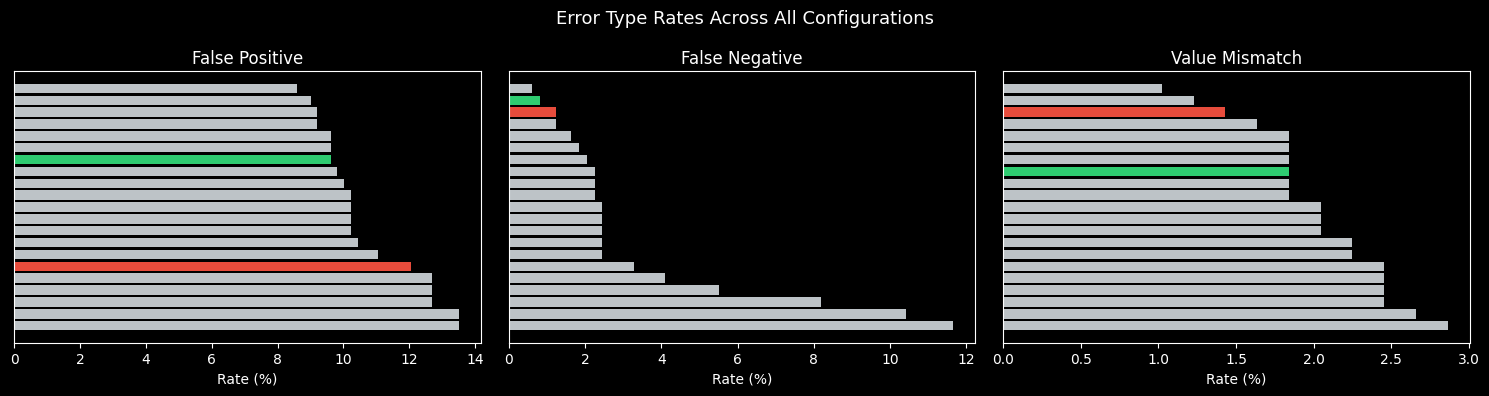

In [25]:
# Classify errors for ALL configs, then compare error type rates
all_classified = evaluated_df.to_dicts()
for row in all_classified:
    row["error_type"] = classify_error(row)
all_classified_df = pl.DataFrame(all_classified)

# Aggregate by config
config_error_rates = []
for (config,), group in all_classified_df.group_by("config"):
    n = group.height
    for err_type in ["false_positive", "false_negative", "value_mismatch"]:
        count = group.filter(pl.col("error_type") == err_type).height
        config_error_rates.append({
            "config": config,
            "error_type": err_type,
            "count": count,
            "rate": count / n,
        })

rates_df = pl.DataFrame(config_error_rates)

# Compare no-RAG vs best RAG
no_rag_rates = rates_df.filter(pl.col("config") == "no_rag")
best_rates = rates_df.filter(pl.col("config") == best_key)

print(f"{'Error Type':<20} {'No RAG':>10} {'Best RAG':>10} {'Delta':>10}")
print(f"{'-'*20} {'-'*10} {'-'*10} {'-'*10}")
for err_type in ["false_positive", "false_negative", "value_mismatch"]:
    nr = no_rag_rates.filter(pl.col("error_type") == err_type)["rate"][0]
    br = best_rates.filter(pl.col("error_type") == err_type)["rate"][0]
    delta = br - nr
    print(f"{err_type:<20} {nr:>9.1%} {br:>9.1%} {delta:>+9.1%}")

# Plot error type rates across all configs
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, err_type in zip(axes, ["false_positive", "false_negative", "value_mismatch"]):
    err_rates = rates_df.filter(pl.col("error_type") == err_type).sort("rate", descending=True)
    colors = ["#e74c3c" if c == "no_rag" else ("#2ecc71" if c == best_key else "#bdc3c7")
              for c in err_rates["config"].to_list()]
    ax.barh(range(err_rates.height), [r * 100 for r in err_rates["rate"].to_list()], color=colors)
    ax.set_title(err_type.replace("_", " ").title())
    ax.set_xlabel("Rate (%)")
    ax.set_yticks([])

fig.suptitle("Error Type Rates Across All Configurations", fontsize=13)
fig.tight_layout()
plt.show()